Task 1:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Creation of dataset from code's 2 to 6 it involves a sample of 1000 results for each Maths, Science and English test results.
np.random.seed(0)

In [3]:
num_samples = 1000

In [4]:
math_scores = np.random.randint(0, 101, num_samples)
science_scores = np.random.randint(0, 101, num_samples)
english_scores = np.random.randint(0, 101, num_samples)

In [5]:
df = pd.DataFrame({
    'Math': math_scores,
    'Science': science_scores,
    'English': english_scores
})


In [6]:
df.to_csv('student_performance.csv', index=False)


Task 2:

In [7]:
# Reading the created .csv file.
pd.read_csv('student_performance.csv')

,Math,Science,English
0,44,69,43
1,47,19,90
2,64,22,15
3,67,11,68
4,67,11,74
...,...,...,...
995,79,71,47
996,41,96,57
997,17,61,21
998,80,1,12


In [8]:
# Converting data array to NumPy
data_array = df.to_numpy()

Task 3:

In [9]:
# Finding NULL or missing values and cleaning if needed - Result shows no NULL values so all good.
print(df.isnull().sum())

Math       0
Science    0
English    0
dtype: int64


In [10]:
# Checking data type for analysis - all highlighted at integer (32) values
print(df.dtypes)

Math       int32
Science    int32
English    int32
dtype: object


Task 4:

In [11]:
# Mean
print(df.mean())

# Median
print(df.median())

# Mode
print(df.mode().iloc[0])  # mode returns a DataFrame

# Range
print(df.max() - df.min())

# Variance
print(df.var())

# Standard Deviation
print(df.std())


Math       50.130
Science    50.293
English    48.776
dtype: float64
Math       50.0
Science    50.0
English    47.0
dtype: float64
Math        0.0
Science    11.0
English    17.0
Name: 0, dtype: float64
Math       100
Science    100
English    100
dtype: int32
Math       868.837938
Science    880.101252
English    833.955780
dtype: float64
Math       29.476057
Science    29.666501
English    28.878293
dtype: float64


In [16]:
# The subject with the highest variance is revealed to be Science as above Variance is the highest at 880.101252
highest_variance_subject = df.var().idxmax()
print(f"Subject with the highest variance is {highest_variance_subject}")

Subject with the highest variance is Science


Task 5:

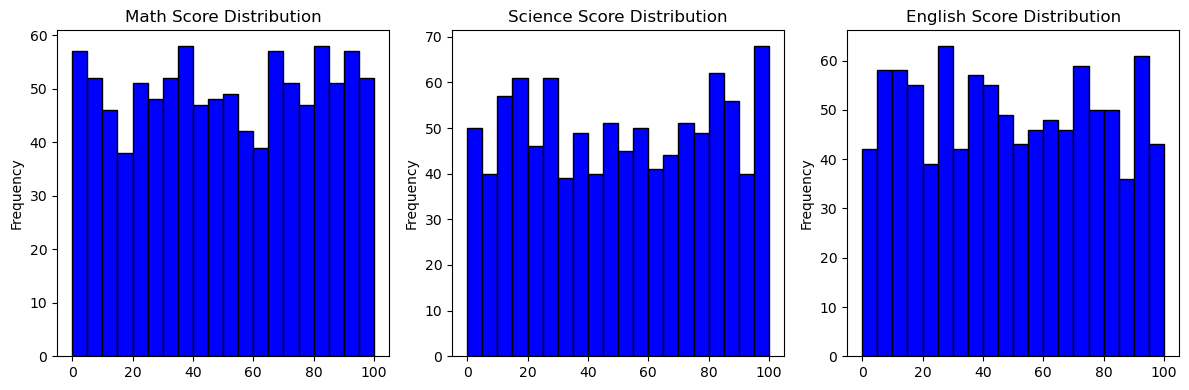

In [19]:
# Histogram for each subject
plt.figure(figsize=(12,4))
for i, subject in enumerate(df.columns):
    plt.subplot(1, 3, i+1)
    plt.hist(df[subject], bins=20, color='blue', edgecolor='black')
    plt.title(f'{subject} Score Distribution')
    plt.ylabel('Score')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

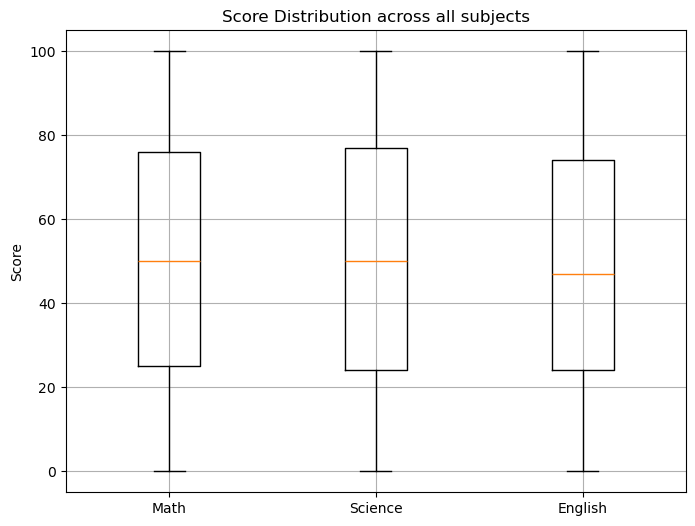

In [22]:
# Boxplot for all subjects
plt.figure(figsize=(8,6))
plt.boxplot([df['Math'], df['Science'], df['English']], labels=df.columns)
plt.title('Score Distribution across all subjects')
plt.ylabel('Score')
plt.grid(True)
plt.show()

Task 6:

In [25]:
#Correlation between three subjects - The resluts indicates from a sample of 1000 students, there is no significant correlation between all three subjects.
correlation_matrix = np.corrcoef(data_array.T)
print('Correlation Matrix:\n', correlation_matrix)
df.corr()

Correlation Matrix:
 [[1.         0.0136976  0.03236734]
 [0.0136976  1.         0.01174914]
 [0.03236734 0.01174914 1.        ]]


,Math,Science,English
Math,1.000000,0.013698,0.032367
Science,0.013698,1.000000,0.011749
English,0.032367,0.011749,1.000000


In [30]:
# Checking for outliers using the Z score, result shows no outliers identified.
from scipy.stats import zscore

z_scores = np.abs(zscore(df))
outliers = (z_scores > 3).any(axis=1)
print(f"Number of potential outliers: {outliers.sum()}")

Number of potential outliers: 0


Summary of interpretation of results

The dataset shows a wide and fairly uniform distribution of scores across all subjects. Math has the most variability, while Science and English are more consistent. No outliers were detected. Correlation analysis reveals minimal relationships between subjects, suggesting that student performance varies independently across disciplines.